# EDA 03: GEO RNA Expression

## Purpose

`3_GEOexpression.txt` pulls RNA measurements from the public **Gene Expression Omnibus (GEO)** —
many independent labs, mostly older microarray-era technology, not one consistent pipeline like
DepMap or HPA. Its value is **breadth**: it may cover cell lines the modern DepMap release does
not. Its cost is a lossy, three-hop identity path and a raw (non-log) scale. This notebook decides
how much of that breadth is actually usable once identity is resolved.

**Source, release, grain:** public GEO microarray/RNA-seq, wide format — rows are genes (Ensembl
IDs), columns are `GSM...` sample accessions. ~19,915 genes × ~3,267 samples.

## Questions this notebook must answer

1. What is the table's grain, and is the value scale really raw (not log-transformed)?
2. How many GEO genes overlap with the primary DepMap RNA layer (notebook 02) — can the two be
   compared at all?
3. Which genes carry the most cross-sample signal?
4. What is the identity path from a `GSM` column to the primary spine (file 10 → file 7 → file 9),
   and how much of the 3,267 samples survive it?
5. Of the samples that do resolve to a cell line, what disease/lineage context do they represent —
   is the usable subset broad or narrow?

**Interpretation rule:** a `GSM` column present in this table is `measured` for that gene
(`docs/PROJECT_ARCHITECTURE.md` §7). A `GSM` column that never resolves to a `ModelID` is not a
missingness case for any cell line — it is simply unusable evidence, excluded before scoring.

## Column dictionary

| Field | Meaning | Notes |
|---|---|---|
| `Gene` | Ensembl gene ID (row key) | |
| `GSM...` columns | one GEO sample accession per column | maps to a cell line via file 10, not directly |
| cell values | raw expression | **not** log-transformed — apply `log1p` before any distributional use |

## 1. Basic data contract and schema audit

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
%%time
df = pd.read_csv(GENE_EXPRESSION / '3_GEOexpression.txt', sep='\t')
sample_cols = [c for c in df.columns if c.startswith('GSM')]
print(f"Genes: {len(df)}   Samples: {len(sample_cols)}")
print(f"Value range: {df[sample_cols].min().min():.1f} - {df[sample_cols].max().max():.1f}")

Genes: 19914   Samples: 3267


Value range: 1.2 - 49877.6
CPU times: total: 14.7 s
Wall time: 15 s


### Why this EDA check matters

Confirms the grain (genes × GEO samples) and, critically, confirms the raw-scale claim from
`data/raw/gene_expression/_.md` — a value range in the hundreds/thousands (not the single digits
seen in notebook 02's already-logged DepMap matrix) means `log1p` is mandatory before any
distributional comparison to the other RNA layers.

## 2. Raw vs log-transformed distribution

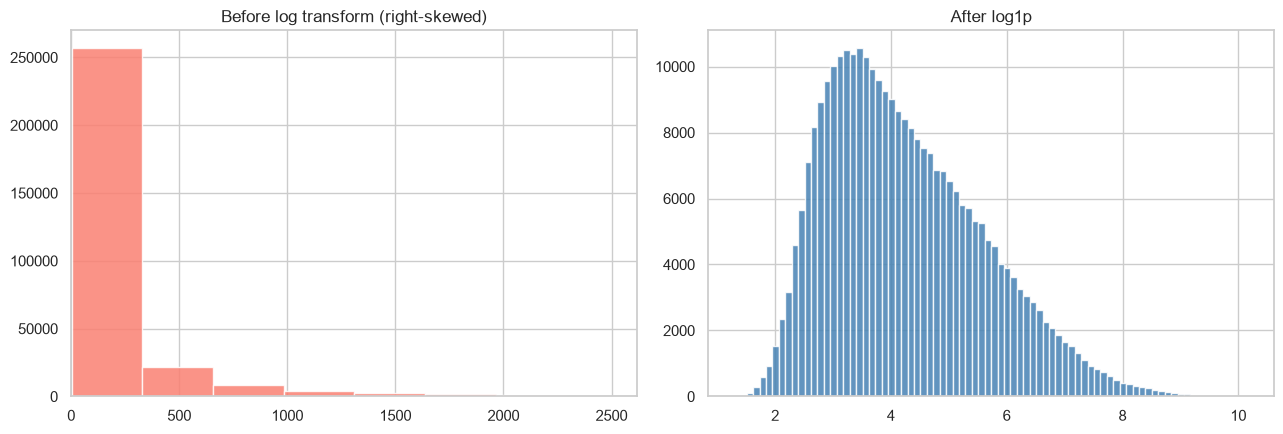

In [3]:
np.random.seed(42)
flat = df[sample_cols].values.flatten()
flat = flat[~np.isnan(flat)]
sample = np.random.choice(flat, min(300_000, len(flat)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(sample, bins=80, color='salmon', edgecolor='white', alpha=0.85)
axes[0].set_xlim(0, np.percentile(sample, 99))
axes[0].set_title('Before log transform (right-skewed)')
axes[1].hist(np.log1p(sample), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('After log1p')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Confirms the right-skew that raw expression counts always show, and that `log1p` restores an
approximately symmetric distribution comparable to the other RNA layers — the same transform
`clean.py` must apply per `scratchpad/kausty/v5/PLAN.md` §7 (P4).

## 3. Gene coverage overlap with the primary DepMap RNA layer

In [4]:
depmap_header = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', nrows=0)
depmap_genes = {m.group(1) for c in depmap_header.columns if (m := re.search(r'(ENSG\d+)', c))}
geo_genes = set(df['Gene'])
overlap = geo_genes & depmap_genes
print(f"GEO genes      : {len(geo_genes)}")
print(f"DepMap genes   : {len(depmap_genes)}")
print(f"Shared genes   : {len(overlap)}  ({len(overlap)/len(geo_genes):.1%} of GEO)")

GEO genes      : 19914
DepMap genes   : 53961
Shared genes   : 19894  (99.9% of GEO)


### Why this EDA check matters

A gene that a researcher includes must be addressable in whichever RNA layer is used for
corroboration. This sets the realistic ceiling: GEO can only corroborate DepMap RNA for genes both
tables carry, never for genes unique to one platform's annotation.

## 4. Per-gene variability and PCA structure

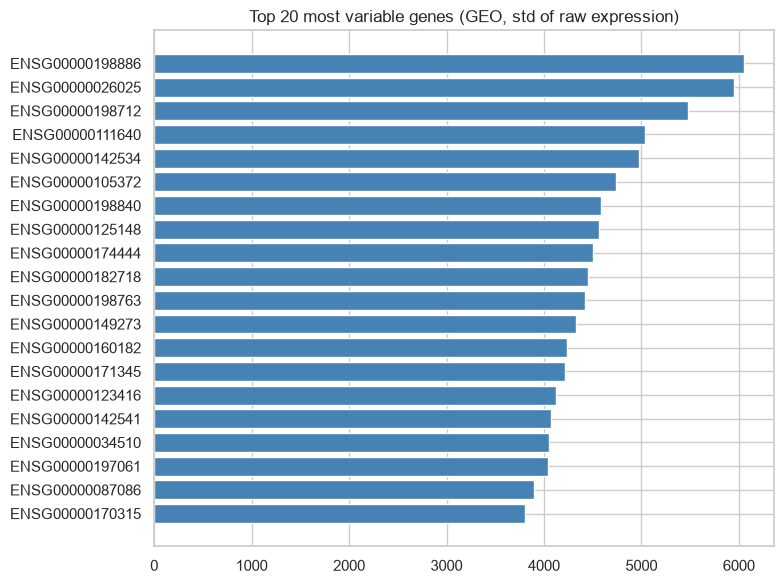

In [5]:
gene_std = df.set_index('Gene')[sample_cols].std(axis=1).sort_values(ascending=False)
top500 = gene_std.head(500).index

fig, ax = plt.subplots(figsize=(8, 6))
top20 = gene_std.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
ax.set_title('Top 20 most variable genes (GEO, std of raw expression)')
plt.tight_layout(); plt.show()

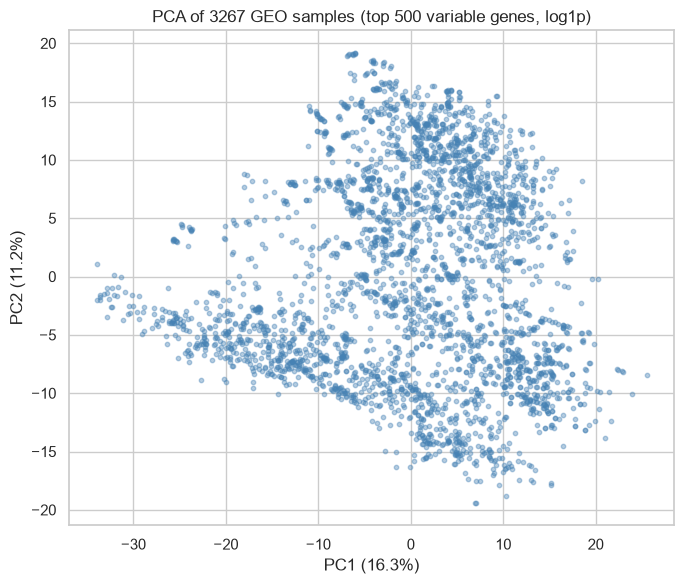

In [6]:
X_geo = np.log1p(df.set_index('Gene').loc[top500, sample_cols].T.values)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_geo)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=10, color='steelblue')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title(f'PCA of {len(sample_cols)} GEO samples (top 500 variable genes, log1p)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Same purpose as notebook 02 §5/§7: identifies which genes carry discriminating signal, and whether
unsupervised structure exists at all before spending effort on identity resolution below. A
formless PCA cloud here would be expected — GEO pools many unrelated studies, so structure is not
guaranteed the way it is within one consistent DepMap batch.

## 5. Identity join path to the primary spine

`GSM` accessions cannot be joined directly to any primary identity table. The path:

| From | Key column | To | Key column | Notes |
|---|---|---|---|---|
| this table | column header (`GSM...`) | file 10 | `Geo_accession` | metadata bridge — many GSMs have no record here at all |
| file 10 | `Cellosaurus_ID` | file 7 | `Accession (CVCL_xxxx)` | name normalisation |
| file 7 | `Accession` (via `RRID`) | file 9 | `RRID` | reaches the primary identity spine |

In [7]:
df10 = pd.read_csv(NOMENCLATURE / '10_GEOInfo.txt', sep='\t',
                    usecols=['Geo_accession', 'Cellosaurus_ID', 'Cellline', 'disease'])
df7 = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv', usecols=['Accession (CVCL_xxxx)'])
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'RRID', 'lineage'])

gsm_cols = set(sample_cols)
hop1 = df10[df10['Geo_accession'].isin(gsm_cols) & df10['Cellosaurus_ID'].notna()]
hop1_match = set(hop1['Geo_accession'])

hop2_cvcl = set(hop1['Cellosaurus_ID']) & set(df7['Accession (CVCL_xxxx)'])
hop3_match = hop2_cvcl & set(df9['RRID'])

print(f"GEO sample columns (this table)                : {len(gsm_cols)}")
print(f"Hop 1 -> file 10 (has a Cellosaurus ID)         : {len(hop1_match)} ({len(hop1_match)/len(gsm_cols):.1%})")
print(f"Hop 2 -> file 7 (accession recognised)          : {len(hop2_cvcl)}")
print(f"Hop 3 -> file 9 (reaches primary spine)         : {len(hop3_match)} ({len(hop3_match)/len(gsm_cols):.1%} of all GSM columns)")

GEO sample columns (this table)                : 3267
Hop 1 -> file 10 (has a Cellosaurus ID)         : 3159 (96.7%)
Hop 2 -> file 7 (accession recognised)          : 797
Hop 3 -> file 9 (reaches primary spine)         : 588 (18.0% of all GSM columns)


### Why this EDA check matters

This is the real usable fraction of GEO, not the raw 3,267-column count — the eligible denominator
for any GEO-corroborated evidence. `docs/PROJECT_ARCHITECTURE.md` §6 criterion A2 (coverage) cannot
be assessed for this layer without this number.

## 6. Disease context of the usable subset

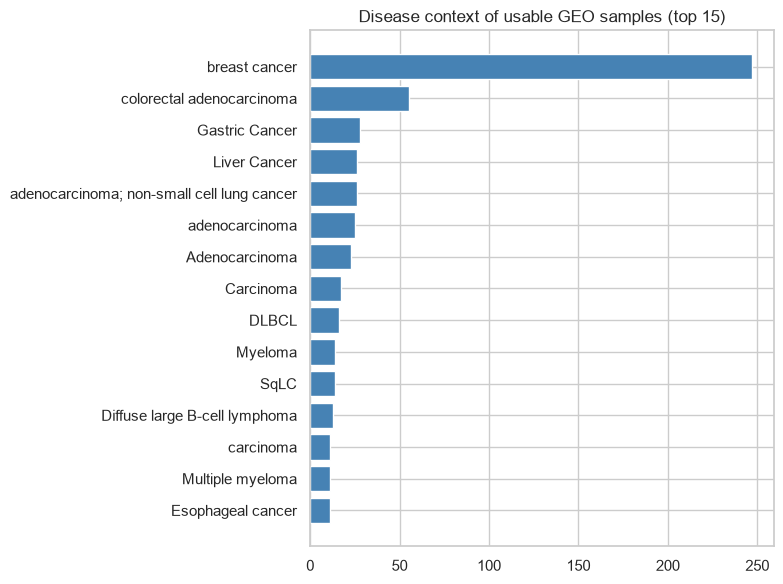

In [8]:
usable = hop1[hop1['Cellosaurus_ID'].isin(hop2_cvcl)]
vc = usable['disease'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(vc.index[::-1], vc.values[::-1], color='steelblue')
ax.set_title('Disease context of usable GEO samples (top 15)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Breadth is only useful if it is not concentrated in the same handful of cancer types the primary
DepMap set already covers well. A disease distribution skewed toward already-well-covered lineages
would mean GEO adds little beyond what notebook 02 already has; a distribution reaching into
under-represented lineages is where GEO earns its place as a corroboration source. **Descriptive
only** — this does not establish that GEO's measurements are *more accurate* for those lineages,
only that they exist there.

## Decisions carried into the next notebooks

1. **GEO values are raw — always `log1p` before comparing to DepMap or HPA.**
2. GEO reaches the primary identity spine through a 3-hop bridge with real, material loss at Hop 1
   (many `GSM` columns have no Cellosaurus match at all) — the usable fraction computed in §5 is the
   correct denominator, not the raw column count.
3. Gene coverage overlap with DepMap RNA (§3) bounds how many genes GEO can ever corroborate.
4. **Limitation:** GEO pools many independent studies with no shared normalisation pipeline: PCA
   structure here reflects study/platform batch effects at least as much as biology, and this
   notebook does not attempt to separate the two.
5. Product role: corroboration/breadth only, same as HPA (notebook 01) — never a standalone scored
   layer without further batch-effect handling (`docs/PROJECT_ARCHITECTURE.md` §6, A3 calibratable
   criterion is open for this layer pending that work).